# 08_GAN_hyperparameter_tuning
Tuning dei learning rate di generatore/discriminatore per il GAN (primo pezzo del metodo generativo GAN+DPS), su Colab con GPU L4.

## Perche' qui il criterio e' diverso da TV/UNet/Weighted TV
Il GAN non ha coppie (input, target) -- il generatore impara a produrre immagini plausibili partendo da rumore, non a trasformare un dato specifico. Quindi non ha senso calcolare PSNR/SSIM qui (non c'e' una singola immagine 'giusta' associata a ciascun output). Il criterio standard in letteratura per confrontare configurazioni GAN e' la **FID (Frechet Inception Distance)**: misura quanto la distribuzione statistica delle immagini generate assomiglia a quella delle immagini vere (piu' bassa = meglio), calcolata con una rete Inception-v3 pre-allenata. La affianco a un'ispezione visiva (griglia di campioni) perche' la FID da sola non basta a scoprire fenomeni come il mode collapse.

## Metodologia
Stesso principio di sempre: si usa il **validation set** (non il test) come riferimento per la FID, per non contaminare la valutazione finale. Si allenano brevemente (poche epoche) diverse combinazioni di learning rate generatore/discriminatore, e si sceglie quella con la FID migliore per l'allenamento completo (notebook successivo).

## Prerequisito
`dataset_resized.zip` su Drive, con dentro `train_resized` (per allenare) e `validation_resized` (riferimento FID).

In [ ]:
# DA ESEGUIRE SU COLAB PER GENERARE I PARAMETRI OTTIMALI PER TRAINING RETE GAN

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DATASET_RESIZED_ZIP = "/content/drive/MyDrive/dataset_resized.zip"
LOCAL_DATASET_DIR = Path("/content/dataset_resized")

if not LOCAL_DATASET_DIR.exists():
    print("Estraggo dataset_resized...")
    get_ipython().system('unzip -q "{DATASET_RESIZED_ZIP}" -d /content/')
else:
    print("dataset_resized gia' estratto, salto.")

TRAIN_DIR = LOCAL_DATASET_DIR / "train_resized"
VALIDATION_DIR = LOCAL_DATASET_DIR / "validation_resized"

assert TRAIN_DIR.exists(), f"Non trovo {TRAIN_DIR}"
assert VALIDATION_DIR.exists(), f"Non trovo {VALIDATION_DIR}"

print(f"Immagini di train: {len(list(TRAIN_DIR.rglob('*.png')))}")
print(f"Immagini di validation: {len(list(VALIDATION_DIR.rglob('*.png')))}")

Mounted at /content/drive
Estraggo dataset_resized...
Immagini di train: 2733
Immagini di validation: 573


In [2]:
get_ipython().system('pip install -q torchmetrics[image]')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.7 MB/s eta 0:00:00


In [3]:
import time
import json

import numpy as np
from skimage import io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchmetrics.image.fid import FrechetInceptionDistance

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo in uso: cuda
GPU: NVIDIA A100-SXM4-40GB


In [4]:
# ============================================================
# Caricamento immagini normalizzate in [0,1] -- stessa logica di
# load_normalized_image gia' usata nel resto della pipeline, riscritta
# qui in locale per non dipendere da moduli esterni al notebook Colab.
# ============================================================

def load_normalized_image(path: Path) -> np.ndarray:
    image = io.imread(path).astype(np.float32)
    max_value = np.iinfo(io.imread(path).dtype).max
    return image / max_value


class CTImageDataset(Dataset):
    def __init__(self, root_dir: Path):
        self.paths = sorted(root_dir.rglob("*.png"))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = load_normalized_image(self.paths[idx])
        return torch.from_numpy(image).float().unsqueeze(0)   # (1, H, W)

In [5]:
# ============================================================
# Architettura DCGAN per immagini 256x256 in scala di grigi.
# Generatore: vettore latente -> immagine, 7 layer transpose-conv
# (4 -> 8 -> 16 -> 32 -> 64 -> 128 -> 256), sigmoid finale per restare
# in [0,1] coerente col resto della pipeline (invece del classico
# tanh in [-1,1] usato in molti DCGAN per immagini RGB).
# Discriminatore: immagine -> logit (vera/falsa), architettura
# speculare con LeakyReLU, nessun sigmoid finale (si usa
# BCEWithLogitsLoss per stabilita' numerica).
# ============================================================

class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 16, 4, 1, 0, bias=False),   # 1x1 -> 4x4
            nn.BatchNorm2d(ngf * 16), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),     # -> 8x8
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),      # -> 16x16
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),      # -> 32x32
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),          # -> 64x64
            nn.BatchNorm2d(ngf), nn.ReLU(True),

            nn.ConvTranspose2d(ngf, ngf // 2, 4, 2, 1, bias=False),         # -> 128x128
            nn.BatchNorm2d(ngf // 2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf // 2, 1, 4, 2, 1, bias=False),           # -> 256x256
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z.view(z.size(0), self.latent_dim, 1, 1))


class Discriminator(nn.Module):
    def __init__(self, ndf=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, ndf // 2, 4, 2, 1, bias=False),                    # 256 -> 128
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf // 2, ndf, 4, 2, 1, bias=False),                  # -> 64
            nn.BatchNorm2d(ndf), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),                   # -> 32
            nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),               # -> 16
            nn.BatchNorm2d(ndf * 4), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),               # -> 8
            nn.BatchNorm2d(ndf * 8), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),              # -> 4
            nn.BatchNorm2d(ndf * 16), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),                    # -> 1x1
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    """Inizializzazione standard DCGAN: aiuta la stabilita' del training."""
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [6]:
# ============================================================
# Configurazione e griglia di tuning
# ============================================================

IMG_SIZE = 256
LATENT_DIM = 100
NGF = 32
NDF = 32

BATCH_SIZE = 32
TUNING_EPOCHS = 15          # allenamenti brevi, solo per confrontare le combinazioni
LABEL_SMOOTHING = 0.9        # le etichette "vere" sono 0.9 invece di 1.0, trucco standard per stabilita'

# Combinazioni (lr_generatore, lr_discriminatore) da confrontare.
# beta1=0.5 e' la convenzione standard per Adam nei GAN (invece del default 0.9).
LR_CANDIDATES = [
    (2e-4, 2e-4),
    (1e-4, 4e-4),
    (2e-4, 1e-4),
    (1e-4, 2e-4),
]

FID_N_SAMPLES = 300   # quante immagini vere/generate usare per calcolare la FID (compromesso costo/stabilita')

train_dataset = CTImageDataset(TRAIN_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2)

print(f"Immagini di train: {len(train_dataset)} -- {len(train_loader)} batch per epoca")
print(f"Combinazioni da testare: {len(LR_CANDIDATES)}")

Immagini di train: 2733 -- 85 batch per epoca
Combinazioni da testare: 4


In [7]:
# ============================================================
# Preparazione del riferimento FID (immagini vere di validation) --
# calcolato una volta sola, riusato per ogni combinazione testata.
# ============================================================

def to_fid_input(x: torch.Tensor) -> torch.Tensor:
    """FID si aspetta immagini RGB in [0,1] float: ripete il canale singolo 3 volte."""
    return x.repeat(1, 3, 1, 1)


val_dataset = CTImageDataset(VALIDATION_DIR)
val_indices = np.random.RandomState(123).choice(len(val_dataset), size=min(FID_N_SAMPLES, len(val_dataset)), replace=False)
real_images = torch.stack([val_dataset[i] for i in val_indices])
print(f"Immagini reali di riferimento per la FID: {real_images.shape[0]}")


def compute_fid(generator, n_samples=FID_N_SAMPLES, batch_size=32):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)

    for i in range(0, real_images.size(0), batch_size):
        batch = real_images[i:i + batch_size].to(DEVICE)
        fid.update(to_fid_input(batch), real=True)

    generator.eval()
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            n = min(batch_size, n_samples - i)
            z = torch.randn(n, LATENT_DIM, device=DEVICE)
            fake = generator(z)
            fid.update(to_fid_input(fake), real=False)
    generator.train()

    return float(fid.compute())

Immagini reali di riferimento per la FID: 300


In [8]:
# ============================================================
# Test rapido: 1 epoca su una combinazione, per stimare il tempo
# totale della griglia prima di lanciarla tutta.
# ============================================================

test_g = Generator(LATENT_DIM, NGF).to(DEVICE)
test_d = Discriminator(NDF).to(DEVICE)
test_g.apply(weights_init)
test_d.apply(weights_init)

opt_g = torch.optim.Adam(test_g.parameters(), lr=LR_CANDIDATES[0][0], betas=(0.5, 0.999))
opt_d = torch.optim.Adam(test_d.parameters(), lr=LR_CANDIDATES[0][1], betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

t0 = time.time()
for real in train_loader:
    real = real.to(DEVICE)
    b = real.size(0)

    # --- Discriminatore ---
    opt_d.zero_grad()
    real_labels = torch.full((b,), LABEL_SMOOTHING, device=DEVICE)
    fake_labels = torch.zeros(b, device=DEVICE)

    loss_d_real = criterion(test_d(real), real_labels)
    z = torch.randn(b, LATENT_DIM, device=DEVICE)
    fake = test_g(z)
    loss_d_fake = criterion(test_d(fake.detach()), fake_labels)
    loss_d = loss_d_real + loss_d_fake
    loss_d.backward()
    opt_d.step()

    # --- Generatore ---
    opt_g.zero_grad()
    loss_g = criterion(test_d(fake), real_labels)
    loss_g.backward()
    opt_g.step()

elapsed = time.time() - t0
n_totale_epoche = TUNING_EPOCHS * len(LR_CANDIDATES)
print(f"Tempo per 1 epoca: {elapsed:.1f} s")
print(f"Stima tempo totale tuning ({n_totale_epoche} epoche totali + calcolo FID): {elapsed * n_totale_epoche / 60:.1f} minuti (indicativo, la FID aggiunge overhead)")

Tempo per 1 epoca: 5.5 s
Stima tempo totale tuning (60 epoche totali + calcolo FID): 5.5 minuti (indicativo, la FID aggiunge overhead)



=== lr_G=0.0002  lr_D=0.0002 ===


lr_G=0.0002 lr_D=0.0002:   0%|          | 0/15 [00:00<?, ?it/s]

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 140MB/s]


FID dopo 15 epoche: 385.09


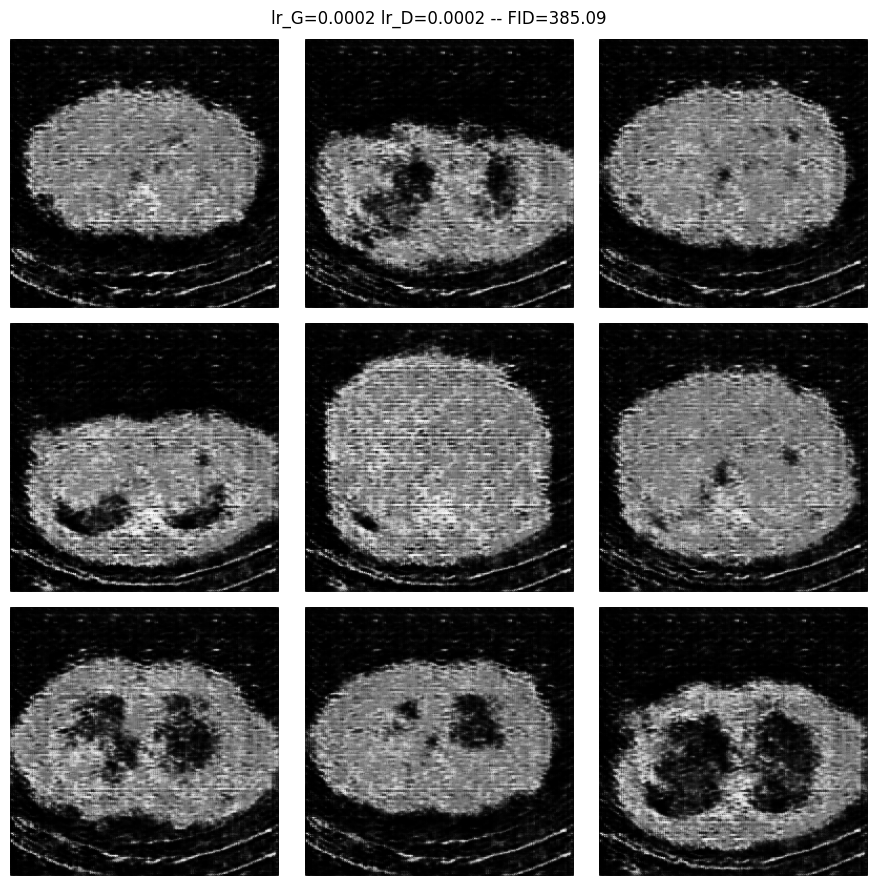


=== lr_G=0.0001  lr_D=0.0004 ===


lr_G=0.0001 lr_D=0.0004:   0%|          | 0/15 [00:00<?, ?it/s]

FID dopo 15 epoche: 519.20


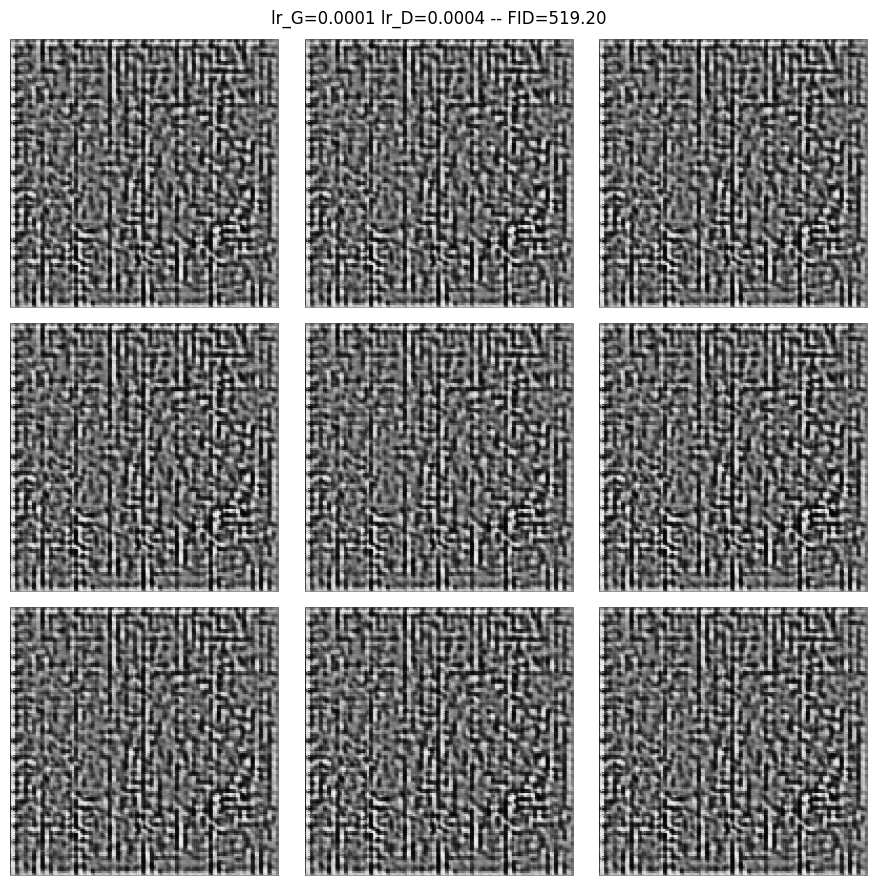


=== lr_G=0.0002  lr_D=0.0001 ===


lr_G=0.0002 lr_D=0.0001:   0%|          | 0/15 [00:00<?, ?it/s]

FID dopo 15 epoche: 396.58


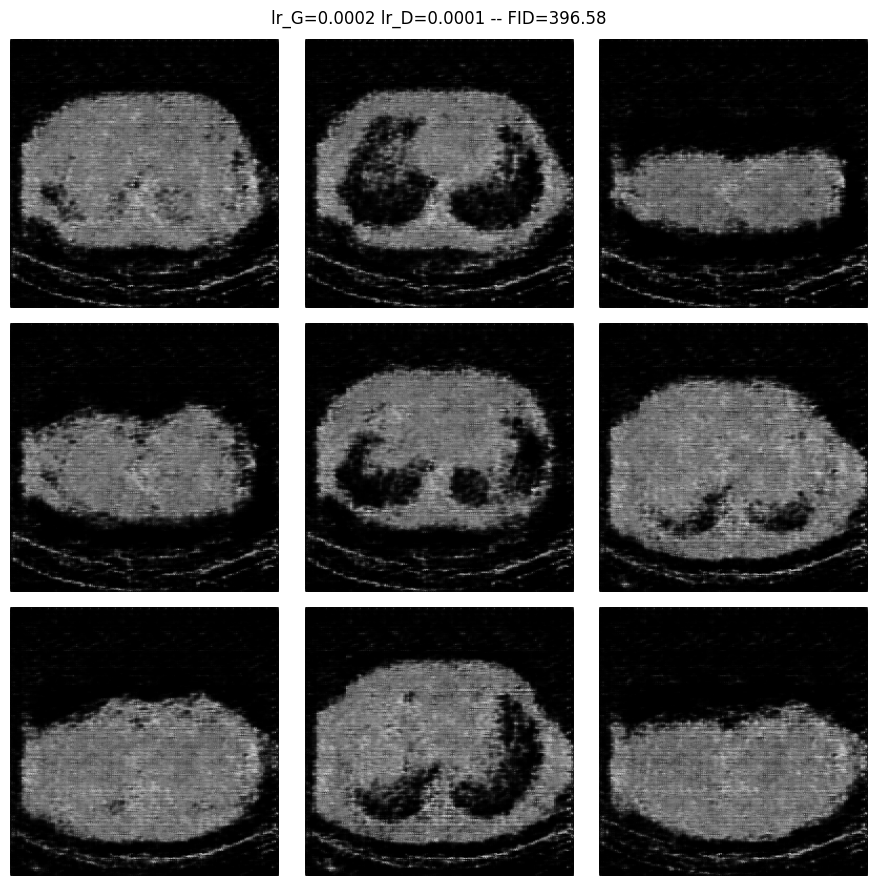


=== lr_G=0.0001  lr_D=0.0002 ===


lr_G=0.0001 lr_D=0.0002:   0%|          | 0/15 [00:00<?, ?it/s]

FID dopo 15 epoche: 403.73


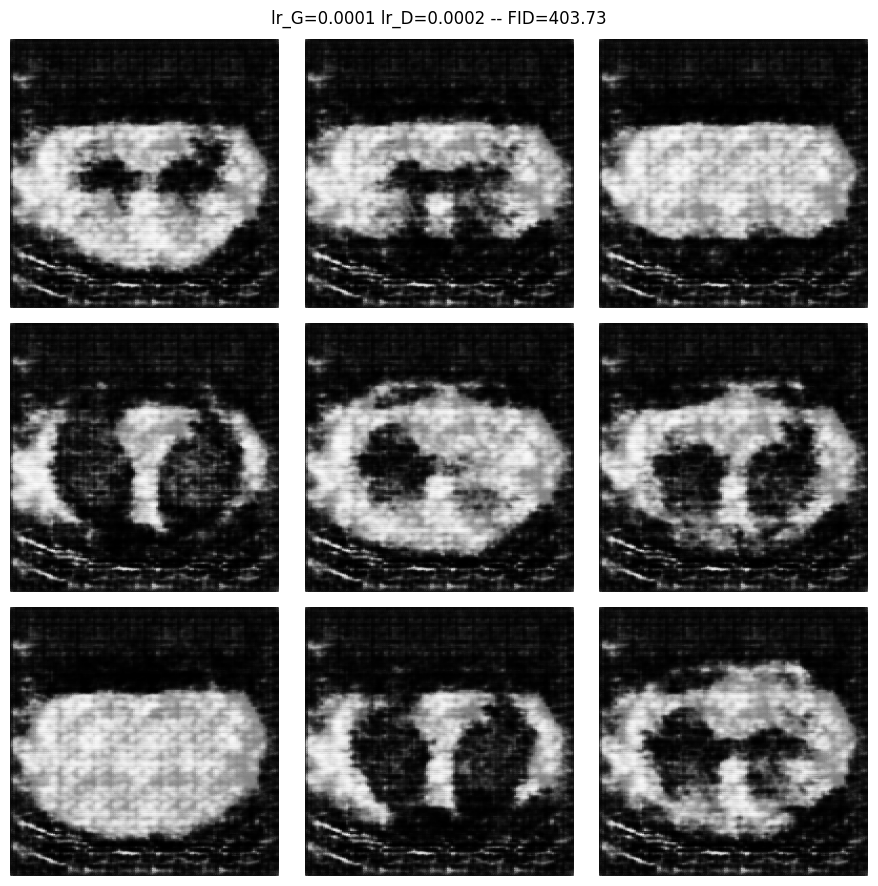

In [9]:
# ============================================================
# GRID SEARCH: allena brevemente ciascuna combinazione, calcola FID
# e salva una griglia di campioni per l'ispezione visiva
# ============================================================

TUNING_DIR = Path("/content/drive/MyDrive/gan_tuning")
TUNING_DIR.mkdir(parents=True, exist_ok=True)

tuning_results = []

for lr_g, lr_d in LR_CANDIDATES:
    print(f"\n=== lr_G={lr_g}  lr_D={lr_d} ===")

    generator = Generator(LATENT_DIM, NGF).to(DEVICE)
    discriminator = Discriminator(NDF).to(DEVICE)
    generator.apply(weights_init)
    discriminator.apply(weights_init)

    opt_g = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    g_losses, d_losses = [], []

    for epoch in tqdm(range(TUNING_EPOCHS), desc=f"lr_G={lr_g} lr_D={lr_d}"):
        epoch_g_loss, epoch_d_loss = 0.0, 0.0

        for real in train_loader:
            real = real.to(DEVICE)
            b = real.size(0)

            opt_d.zero_grad()
            real_labels = torch.full((b,), LABEL_SMOOTHING, device=DEVICE)
            fake_labels = torch.zeros(b, device=DEVICE)

            loss_d_real = criterion(discriminator(real), real_labels)
            z = torch.randn(b, LATENT_DIM, device=DEVICE)
            fake = generator(z)
            loss_d_fake = criterion(discriminator(fake.detach()), fake_labels)
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            opt_d.step()

            opt_g.zero_grad()
            loss_g = criterion(discriminator(fake), real_labels)
            loss_g.backward()
            opt_g.step()

            epoch_g_loss += loss_g.item()
            epoch_d_loss += loss_d.item()

        g_losses.append(epoch_g_loss / len(train_loader))
        d_losses.append(epoch_d_loss / len(train_loader))

    fid_score = compute_fid(generator)
    print(f"FID dopo {TUNING_EPOCHS} epoche: {fid_score:.2f}")

    # Griglia di campioni per ispezione visiva
    generator.eval()
    with torch.no_grad():
        z = torch.randn(9, LATENT_DIM, device=DEVICE)
        samples = generator(z).cpu().numpy()
    generator.train()

    fig, axs = plt.subplots(3, 3, figsize=(9, 9))
    for ax, img in zip(axs.flat, samples):
        ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    plt.suptitle(f"lr_G={lr_g} lr_D={lr_d} -- FID={fid_score:.2f}")
    plt.tight_layout()
    fname = f"samples_lrG{lr_g}_lrD{lr_d}.png"
    plt.savefig(TUNING_DIR / fname, dpi=120)
    plt.show()

    tuning_results.append({
        "lr_g": lr_g, "lr_d": lr_d, "fid": fid_score,
        "g_losses": g_losses, "d_losses": d_losses,
    })

In [10]:
# ============================================================
# Selezione della combinazione migliore (FID piu' bassa) + salvataggio
# ============================================================

tuning_results.sort(key=lambda r: r["fid"])

print("=== Classifica (dalla migliore) ===")
for r in tuning_results:
    print(f"lr_G={r['lr_g']:<8} lr_D={r['lr_d']:<8} FID={r['fid']:.2f}")

best = tuning_results[0]
print(f"\nMigliore combinazione: lr_G={best['lr_g']}, lr_D={best['lr_d']} (FID={best['fid']:.2f})")

with open(TUNING_DIR / "best_gan_lr.json", "w") as f:
    json.dump({"lr_g": best["lr_g"], "lr_d": best["lr_d"], "fid": best["fid"]}, f, indent=2)

with open(TUNING_DIR / "full_tuning_results.json", "w") as f:
    json.dump(tuning_results, f, indent=2)

print(f"\nSalvato in: {TUNING_DIR}")

=== Classifica (dalla migliore) ===
lr_G=0.0002   lr_D=0.0002   FID=385.09
lr_G=0.0002   lr_D=0.0001   FID=396.58
lr_G=0.0001   lr_D=0.0002   FID=403.73
lr_G=0.0001   lr_D=0.0004   FID=519.20

Migliore combinazione: lr_G=0.0002, lr_D=0.0002 (FID=385.09)

Salvato in: /content/drive/MyDrive/gan_tuning


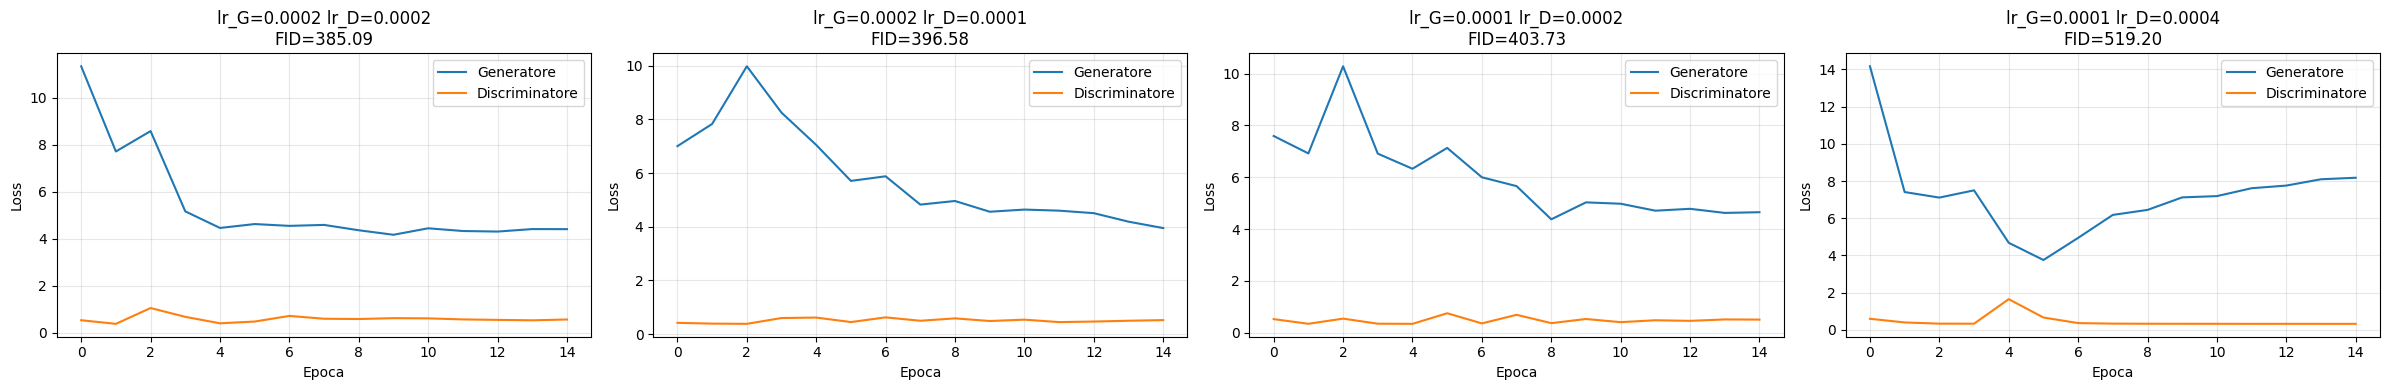

In [11]:
# ============================================================
# Curve di loss di generatore/discriminatore per ciascuna combinazione
# -- utile per controllare la stabilita' del training (es. loss del
# discriminatore che crolla a zero troppo in fretta e' un campanello
# di allarme, il generatore smette di ricevere gradiente utile)
# ============================================================

fig, axs = plt.subplots(1, len(tuning_results), figsize=(6 * len(tuning_results), 4))
if len(tuning_results) == 1:
    axs = [axs]

for ax, r in zip(axs, tuning_results):
    ax.plot(r["g_losses"], label="Generatore")
    ax.plot(r["d_losses"], label="Discriminatore")
    ax.set_title(f"lr_G={r['lr_g']} lr_D={r['lr_d']}\nFID={r['fid']:.2f}")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(TUNING_DIR / "loss_curves_comparison.png", dpi=150)
plt.show()

## Prossimo passo
Usa `lr_g`/`lr_d` da `best_gan_lr.json` (o quella che preferisci dopo aver ispezionato campioni e curve di loss -- la FID e' una guida, non un verdetto assoluto) nel notebook di training completo (`09_GAN_training.ipynb`), che allena per molte piu' epoche con checkpoint su Drive.